In [3]:
# Установка зависимостей
!pip install supervision opencv-python pillow matplotlib
!pip install inference-sdk requests numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.4/212.4 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 MB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 2.1 MB/s eta 0:00:00
  Attempting uninstall: opencv-python
    Found existing installation: opencv-python 4.12.0.88
    Uninstalling opencv-python-4.12.0.88:
      Successfully uninstalled opencv-python-4.12.0.88
  Attempting uninstall: aiohttp
    Found existing installation: aiohttp 3.13.2
    Uninstalling aiohttp-3.13.2:
      Successfully uninstalled aiohttp-3.13.2


In [1]:
import cv2
import supervision as sv
import numpy as np
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt
from inference_sdk import InferenceHTTPClient
from collections import Counter
import time



In [2]:
# URL тестового изображения
IMAGE_URL = "https://i.ibb.co/RGsG2tmC/1487344021120679825.jpg"

# Ваш API ключ Roboflow
ROBOFLOW_API_KEY = "V7IEaJCQ6iSNFL1l5oa9"

# Частоты ультразвука для разных хищников (в кГц)
ULTRASOUND_FREQUENCIES = {
    "wolf": 25,    # Волки - низкие частоты
    "fox": 30,     # Лисы - средние частоты
    "marten": 35,  # Куницы - высокие частоты
    "weasel": 40   # Хорьки - очень высокие частоты
}

print("СИСТЕМА ЗАЩИТЫ КУРИНОГО ВОЛЬЕРА")

СИСТЕМА ЗАЩИТЫ КУРИНОГО ВОЛЬЕРА


In [3]:
# Создается экземпляр клиента для общения с Roboflow API
client = InferenceHTTPClient(
    api_url="https://serverless.roboflow.com",
    api_key=ROBOFLOW_API_KEY
)

print("Клиент Roboflow инициализирован")

Клиент Roboflow инициализирован


In [4]:
# Загружаем изображение по URL
response = requests.get(IMAGE_URL)

# Преобразуем байты в изображение
image = Image.open(BytesIO(response.content)).convert("RGB")

# Превращаем PIL-изображение в NumPy-массив
image_np = np.array(image)

print(f"Изображение загружено: {image.size[0]}x{image.size[1]} пикселей")

Изображение загружено: 640x427 пикселей


In [ ]:
# Отправляем изображение на сервер для обработки
print("Запуск обнаружения хищников..")

result = client.run_workflow(
    workspace_name="weed-detector-for-family-farm",
    workflow_id="find-wolves-foxes-martens-and-weasels",
    images={"image": IMAGE_URL},
    use_cache=True
)

print("Детекция завершена")

Запуск обнаружения хищников...
Детекция завершена


In [6]:
# Обрабатываем результаты
prediction_data = result[0]
detections = sv.Detections.from_inference(prediction_data["predictions"])

# Наши целевые хищники
TARGET_PREDATORS = ["wolf", "fox", "marten", "weasel"]

# Фильтруем только целевых хищников
filtered_indices = []
predators_found = []

for i, class_name in enumerate(detections.data["class_name"]):
    if class_name in TARGET_PREDATORS:
        filtered_indices.append(i)
        predators_found.append(class_name)

if filtered_indices:
    filtered_detections = detections[filtered_indices]
else:
    filtered_detections = sv.Detections.empty()

print(f"Обнаружено объектов: {len(detections)}")
print(f"Целевых хищников: {len(predators_found)}")

Обнаружено объектов: 1
Целевых хищников: 1


In [7]:
def activate_ultrasound(predators_list):
    """
    Активирует ультразвуковой отпугиватель для обнаруженных хищников
    """

    if not predators_list:
        print("Ультразвук не требуется - хищники не обнаружены")
        return

    print("\n🔊 АКТИВАЦИЯ УЛЬТРАЗВУКОВОГО ОТПУГИВАТЕЛЯ")

    # Для каждого типа хищника активируем свою частоту
    for predator_type in set(predators_list):
        if predator_type in ULTRASOUND_FREQUENCIES:
            frequency = ULTRASOUND_FREQUENCIES[predator_type]

            print(f"{predator_type.upper()}: частота {frequency} кГц")

            # Имитация включения ультразвука
            print(f"   🔊 Включаем ультразвук {frequency} кГц...")

            # Визуализация звуковых волн
            for i in range(3):
                print(f"      {'🔊' * (i+1)} Генерация волны {i+1}...")
                time.sleep(0.3)

    print(f"Отпугиватель активирован на 5 минут")

# Проверяем и активируем ультразвук если нужно
activate_ultrasound(predators_found)


🔊 АКТИВАЦИЯ УЛЬТРАЗВУКОВОГО ОТПУГИВАТЕЛЯ
FOX: частота 30 кГц
   🔊 Включаем ультразвук 30 кГц...
      🔊 Генерация волны 1...
      🔊🔊 Генерация волны 2...
      🔊🔊🔊 Генерация волны 3...
Отпугиватель активирован на 5 минут


In [9]:
# Создаем аннотаторы
box_annotator = sv.BoxAnnotator(
    color=sv.Color(r=255, g=128, b=255),
    thickness=5
)

# Label аннотатор
label_annotator = sv.LabelAnnotator(
    text_color=sv.Color(r=128, g=128, b=128),
    text_padding=8,
    text_scale=1.5
)

# Формирование списка подписей
labels = []
if len(filtered_detections) > 0:
    for class_name in filtered_detections.data["class_name"]:
        if class_name in TARGET_PREDATORS:
            labels.append(f"{class_name}")



In [10]:
# Создаем копию изображения для аннотации
annotated_image = image_np.copy()

if len(filtered_detections) > 0:

    # Создаем временное изображение для отрисовки
    temp_image = annotated_image.copy()

    # Сначала рисуем рамки
    temp_image = box_annotator.annotate(
        scene=temp_image,
        detections=filtered_detections
    )


    # Затем добавляем подписи
    temp_image = label_annotator.annotate(
        scene=temp_image,
        detections=filtered_detections,
        labels=labels
    )

    # Применяем изменения
    annotated_image = temp_image
    print(" Визуализация завершена")


 Визуализация завершена


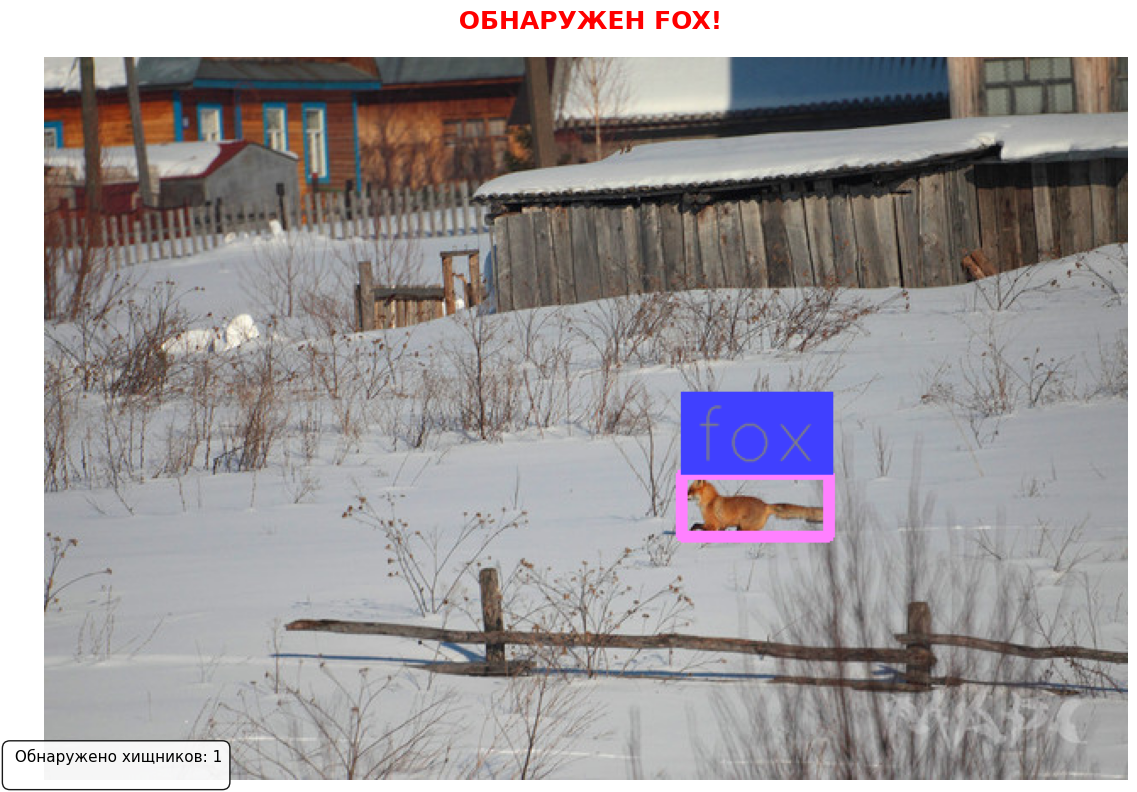

In [11]:
# Настраиваем размер графика
plt.figure(figsize=(12, 8))

if predators_found:
    plt.imshow(annotated_image)

    # Определяем главного хищника
    main_predator = Counter(predators_found).most_common(1)[0][0]

    plt.title(f" ОБНАРУЖЕН {main_predator.upper()}!",
              fontsize=18, fontweight='bold', color='red', pad=20)

    # Информация об обнаружении
    info_text = f" Обнаружено хищников: {len(predators_found)}\n"
    if len(set(predators_found)) > 1:
        info_text += " Виды: " + ", ".join(set(predators_found))

    plt.figtext(0.02, 0.02, info_text, fontsize=11,
               bbox=dict(boxstyle="round,pad=0.5", facecolor="white", alpha=0.9))

else:
    plt.imshow(annotated_image)
    plt.title(" ХИЩНИКИ НЕ ОБНАРУЖЕНЫ",
              fontsize=18, fontweight='bold', color='green', pad=20)

# Убираем оси
plt.axis('off')

# Показываем результат
plt.tight_layout()
plt.show()

In [12]:

print(" РЕЗУЛЬТАТЫ АНАЛИЗА")


if predators_found:
    total_count = len(predators_found)
    main_predator = Counter(predators_found).most_common(1)[0][0]

    print(f" ОБНАРУЖЕНО ХИЩНИКОВ: {total_count}")

    if len(set(predators_found)) > 1:
        print("\n Распределение по видам:")
        for predator, count in Counter(predators_found).items():
            print(f"   • {predator}: {count} особей")

    # Активация ультразвука
    print(f"\n🔊 АКТИВАЦИЯ УЛЬТРАЗВУКА:")
    for predator in set(predators_found):
        frequency = ULTRASOUND_FREQUENCIES.get(predator, "неизвестно")
        print(f"   • {predator}: {frequency} кГц")

    print(f"\nОсновная угроза: {main_predator}")

else:
    print(" Хищники на участке не обнаружены")

print("\nСистема защиты завершила работу")


 РЕЗУЛЬТАТЫ АНАЛИЗА
 ОБНАРУЖЕНО ХИЩНИКОВ: 1

🔊 АКТИВАЦИЯ УЛЬТРАЗВУКА:
   • fox: 30 кГц

Основная угроза: fox

Система защиты завершила работу
